# DINOv2/v3 probe -- does a pretrained natural-image encoder help on ARC-AGI-3 frames?

Empirical check of the assumption in `ARCHITECTURE.md` ("Why not a natural-image
pretrained encoder") -- that reasoning was never actually tested, just argued
from the domain mismatch (flat color blocks vs. natural-image statistics).
Fair to test directly instead of assuming (DESIGN_LOG 2026-08-20).

**What this notebook checks, on a handful of `ls20` frames:**
1. *Qualitative* -- PCA of DINO's patch tokens, the classic "does it segment
   objects" visualization from the DINO papers. If DINOv2/v3's frozen features
   still cleanly separate ARC's sprites from background despite having never
   seen anything like this distribution, that's a real signal.
2. *Quantitative* -- does embedding distance between two frames track how
   different the frames actually are at the pixel level? Compared three ways:
   frozen pretrained DINOv2, a random-init ViT of the *same architecture*
   (isolates "pretraining helps" from "a big enough random projection would
   already separate things"), and this project's own tiny trained-from-scratch
   `Eyes` encoder (`checkpoints/world_model_pretrained.pt`, Stage 1 JEPA
   pretraining, TODO item 3).

Standalone notebook, not wired into the training pipeline -- a probe, not a
dependency. If this turns up a clear signal either way, feed the result back
into `ARCHITECTURE.md`/`DESIGN_LOG.md` before touching `jepa_pretrain.ipynb`.

## Setup

In [1]:
import os
from pathlib import Path

ON_KAGGLE = Path("/kaggle/input").exists()
COMP_DIR = Path("/kaggle/input/arc-prize-2026-arc-agi-3") if ON_KAGGLE else Path("../data")
os.environ["OPERATION_MODE"] = "offline"
os.environ["ENVIRONMENTS_DIR"] = str(COMP_DIR / "environment_files")

import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import pearsonr, spearmanr

from arc_agi import Arcade
from arcengine import GameAction, GameState

SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Running on Kaggle:", ON_KAGGLE)
print("torch:", torch.__version__, "| cuda:", torch.cuda.is_available())

Running on Kaggle: False
torch: 2.13.0+cu130 | cuda: True


## Collect a handful of `ls20` frames

Same random-legal-action collection as `jepa_pretrain.ipynb`, just a small
budget -- this is a probe, not a training run. Two short episodes (reset in
between) for a bit of state diversity, capped at a modest frame count so the
qualitative plots below stay readable.

In [2]:
ACTION_SPACE = [GameAction.ACTION1, GameAction.ACTION2, GameAction.ACTION3,
                 GameAction.ACTION4, GameAction.ACTION5, GameAction.ACTION7]
ACTION_ID_TO_INDEX = {a.value: i for i, a in enumerate(ACTION_SPACE)}

GAME = "ls20"
arc = Arcade()
env = arc.make(GAME)

N_FRAMES = 40
MAX_EPISODE_STEPS = 25

grids = []  # list of (64, 64) uint8 arrays
frame = env.reset()
episode_steps = 0
while len(grids) < N_FRAMES:
    if frame.state != GameState.NOT_FINISHED or episode_steps >= MAX_EPISODE_STEPS:
        frame = env.reset()
        episode_steps = 0
    legal = [a for a in frame.available_actions if a in ACTION_ID_TO_INDEX]
    if not legal:
        frame = env.reset()
        episode_steps = 0
        legal = [a for a in frame.available_actions if a in ACTION_ID_TO_INDEX]
    grids.append(frame.frame[0].copy().astype(np.uint8))
    action_idx = ACTION_ID_TO_INDEX[random.choice(legal)]
    frame = env.step(ACTION_SPACE[action_idx])
    episode_steps += 1

print(f"collected {len(grids)} frames, shape {grids[0].shape}, value range "
      f"[{min(g.min() for g in grids)}, {max(g.max() for g in grids)}]")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-08-26 18:00:29 | INFO | Created new scorecard: 79414256-42fd-40b3-ba0c-4f36236c0ff1
2026-08-26 18:00:29 | INFO | Found latest version of ls20: ls20-9607627b (downloaded: 2026-04-08 20:07:48.377805+00:00)
2026-08-26 18:00:29 | INFO | Successfully loaded game class Ls20 from ../data/environment_files/ls20/9607627b/ls20.py
collected 40 frames, shape (64, 64), value range [0, 12]


## Frame -> RGB, and the three encoders

- **Grid -> RGB**: same `vmin=0, vmax=15` colormap convention already used to
  render trajectories elsewhere in this project (`tab20` here for 16 distinct
  flat colors), nearest-neighbor upscaled to 224x224 so DINO's patch grid
  (14px patches -> 16x16 patches) gets a reasonably sized image without
  blurring the hard edges that are the whole point of ARC's grid structure.
- **DINOv2-small** (`facebook/dinov2-small`, ~22M params, Apache 2.0, not
  gated): frozen, eval mode.
- **Random-init control**: same architecture/config as DINOv2-small, weights
  re-initialized from scratch (`AutoModel.from_config`) -- isolates what
  *pretraining* specifically contributes vs. just having a same-sized ViT.
- **Our own `Eyes`** (from `checkpoints/world_model_pretrained.pt`): verbatim
  class defs from `jepa_pretrain.ipynb` Stage 1, loaded frozen. Only the
  encoder, no Brain/Intuition needed for this probe.

In [3]:
from transformers import AutoModel, AutoConfig

DINO_ID = "facebook/dinov2-small"
IMG_SIZE = 224  # divisible by dinov2's patch_size=14 -> 16x16 = 256 patches

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1)


def grid_to_rgb_tensor(grid, size=IMG_SIZE, cmap_name="tab20"):
    """(64,64) uint8 grid, values 0-15 -> (1,3,size,size) normalized tensor,
    nearest-neighbor upscaled to preserve hard edges (no anti-aliasing)."""
    cmap = plt.get_cmap(cmap_name, 16)
    rgb = cmap(grid)[..., :3].astype(np.float32)  # (64, 64, 3) in [0, 1]
    t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)  # (1, 3, 64, 64)
    t = F.interpolate(t, size=(size, size), mode="nearest")
    t = (t - IMAGENET_MEAN) / IMAGENET_STD
    return t


print("loading DINOv2-small (downloads on first run)...")
dino = AutoModel.from_pretrained(DINO_ID)
dino.eval()
for p in dino.parameters():
    p.requires_grad_(False)

random_vit = AutoModel.from_config(AutoConfig.from_pretrained(DINO_ID))
random_vit.eval()
for p in random_vit.parameters():
    p.requires_grad_(False)

print(f"DINOv2-small params: {sum(p.numel() for p in dino.parameters()):,}")
print(f"random-init control params: {sum(p.numel() for p in random_vit.parameters()):,} (same architecture)")

loading DINOv2-small (downloads on first run)...


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

DINOv2-small params: 22,056,576
random-init control params: 22,056,576 (same architecture)


In [4]:
# --- our own from-scratch Eyes (verbatim from jepa_pretrain.ipynb Stage 1) ---
class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, max_len: int = 4096, theta: float = 10000.0):
        super().__init__()
        self.dim = dim
        inv_freq = 1.0 / (theta ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        t = torch.arange(max_len, dtype=torch.float32)
        freqs = torch.outer(t, self.inv_freq)
        emb = torch.cat((freqs, freqs), dim=-1)
        self.register_buffer("cos_cached", emb.cos(), persistent=False)
        self.register_buffer("sin_cached", emb.sin(), persistent=False)

    def _rotate_half(self, x):
        x1 = x[..., :self.dim // 2]
        x2 = x[..., self.dim // 2:]
        return torch.cat((-x2, x1), dim=-1)

    def apply_rope(self, x, cos, sin):
        cos = cos.unsqueeze(0).unsqueeze(1)
        sin = sin.unsqueeze(0).unsqueeze(1)
        return (x * cos) + (self._rotate_half(x) * sin)


class patch_embedding(nn.Module):
    def __init__(self, input_dim, patch_size, output_dim, image_size=64):
        super().__init__()
        self.patch_size = patch_size
        self.grid_size = image_size // patch_size
        self.proj = nn.Conv2d(input_dim, output_dim, kernel_size=patch_size, stride=patch_size)
        rows = torch.arange(self.grid_size).repeat_interleave(self.grid_size)
        cols = torch.arange(self.grid_size).repeat(self.grid_size)
        self.register_buffer("rows", rows, persistent=False)
        self.register_buffer("cols", cols, persistent=False)

    def forward(self, x):
        x = self.proj(x)
        return x.flatten(2).transpose(1, 2)


class RoPEAttention(nn.Module):
    def __init__(self, embed_dim, num_heads, grid_size):
        super().__init__()
        assert embed_dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        assert self.head_dim % 4 == 0
        self.axial_dim = self.head_dim // 2
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out_proj = nn.Linear(embed_dim, embed_dim)
        self.row_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)
        self.col_rope = RotaryEmbedding(dim=self.axial_dim, max_len=grid_size)

    def _apply_2d_rope(self, x, rows, cols):
        x_row, x_col = x[..., :self.axial_dim], x[..., self.axial_dim:]
        row_cos, row_sin = self.row_rope.cos_cached[rows], self.row_rope.sin_cached[rows]
        col_cos, col_sin = self.col_rope.cos_cached[cols], self.col_rope.sin_cached[cols]
        x_row = self.row_rope.apply_rope(x_row, row_cos, row_sin)
        x_col = self.col_rope.apply_rope(x_col, col_cos, col_sin)
        return torch.cat([x_row, x_col], dim=-1)

    def forward(self, x, rows, cols):
        batch_size, seq_len, embed_dim = x.shape
        qkv = self.qkv(x).view(batch_size, seq_len, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        q = self._apply_2d_rope(q, rows, cols)
        k = self._apply_2d_rope(k, rows, cols)
        attn_out = F.scaled_dot_product_attention(q, k, v)
        attn_out = attn_out.transpose(1, 2).contiguous().view(batch_size, seq_len, embed_dim)
        return self.out_proj(attn_out)


class RoPETransformerEncoderLayer(nn.Module):
    def __init__(self, embed_dim, num_heads, grid_size, ff_dim=None):
        super().__init__()
        ff_dim = ff_dim or embed_dim * 4
        self.attention = RoPEAttention(embed_dim, num_heads, grid_size)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(nn.Linear(embed_dim, ff_dim), nn.GELU(), nn.Linear(ff_dim, embed_dim))

    def forward(self, x, rows, cols):
        x = x + self.attention(self.norm1(x), rows, cols)
        x = x + self.mlp(self.norm2(x))
        return x


class Transformer(nn.Module):
    def __init__(self, input_dim, output_dim, num_heads, num_layers, patch_size):
        super().__init__()
        self.embedding = patch_embedding(input_dim, patch_size, output_dim)
        self.layers = nn.ModuleList([
            RoPETransformerEncoderLayer(output_dim, num_heads, self.embedding.grid_size)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(output_dim, output_dim)

    def forward(self, x):
        x = self.embedding(x)
        rows, cols = self.embedding.rows, self.embedding.cols
        for layer in self.layers:
            x = layer(x, rows, cols)
        return self.fc_out(x)


class Eyes(nn.Module):
    def __init__(self, encoder):
        super().__init__()
        self.encoder = encoder

    def forward(self, x):
        return self.encoder(x).mean(dim=1)


# Scaled up 2026-08-20 (DESIGN_LOG) after this probe first ran -- eyes_layers 1->6, output_dim(latent_dim) 16->192, num_heads 2->6, trained on GPU with more data.
eyes = Eyes(Transformer(input_dim=1, output_dim=192, num_heads=6, num_layers=6, patch_size=4))
ckpt_path = Path("../checkpoints/world_model_pretrained.pt")
if ckpt_path.exists():
    ckpt = torch.load(ckpt_path, map_location="cpu")
    eyes.load_state_dict(ckpt["eyes"])
    print(f"loaded {ckpt_path} -- eyes params: {sum(p.numel() for p in eyes.parameters()):,}")
else:
    print(f"WARNING: {ckpt_path} not found -- run jepa_pretrain.ipynb Stage 1 first. "
          "Falling back to a random-init Eyes for this probe (not comparable to the real thing).")
eyes.eval()
for p in eyes.parameters():
    p.requires_grad_(False)


def eyes_input_tensor(grid):
    return torch.from_numpy(grid).float().unsqueeze(0).unsqueeze(0)  # (1, 1, 64, 64), native resolution

loaded ../checkpoints/world_model_pretrained.pt -- eyes params: 2,709,504


## Qualitative check -- PCA of DINO's patch tokens

The classic DINO visualization: project the patch-token features to 3
principal components and render as RGB. In the original papers this cleanly
segments foreground objects from background on natural images. Here: does it
do anything meaningful on flat-color synthetic grids it's never seen, or is
it just noise?

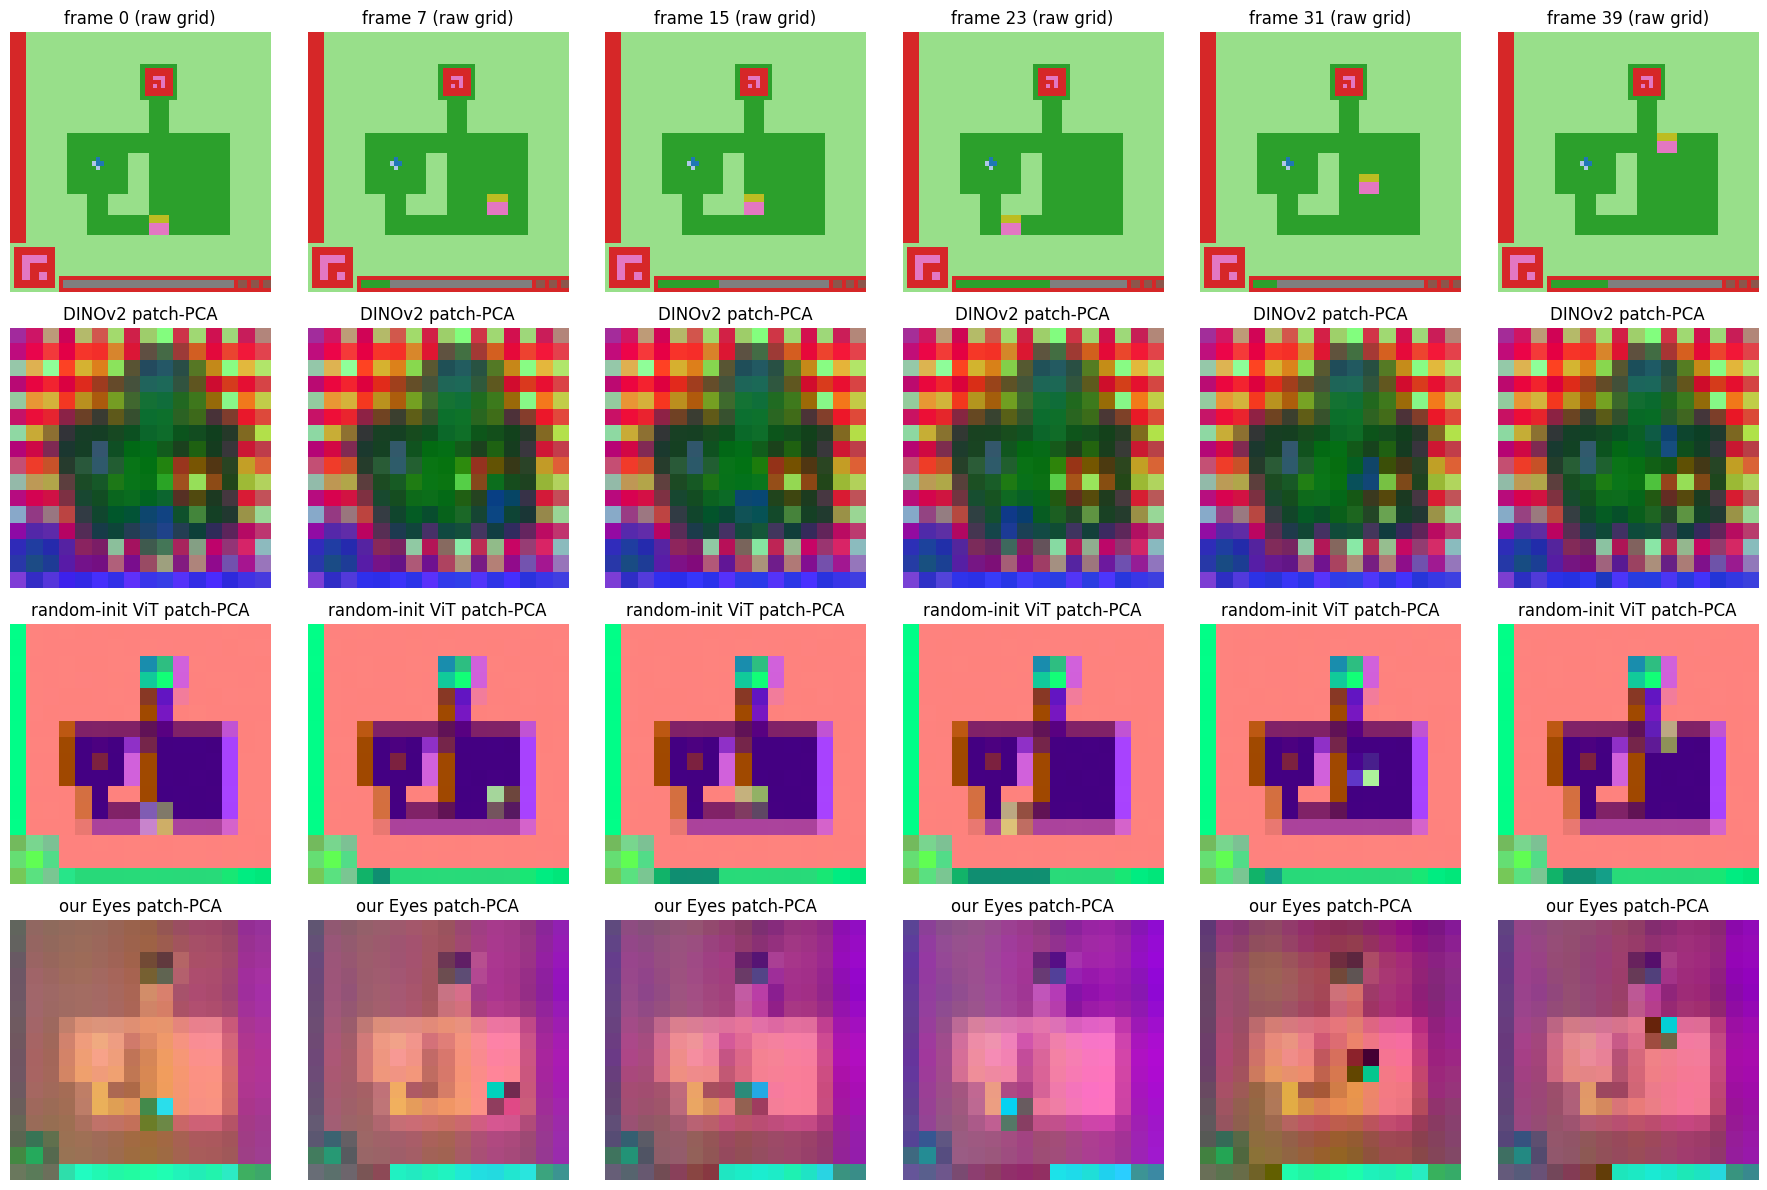

PCA fit once per encoder across all shown frames (not per-frame) -- colors are now comparable across columns within each row.


In [5]:
def dino_patches(model, x):
    with torch.no_grad():
        out = model(pixel_values=x).last_hidden_state  # (1, 1+num_patches, dim) -- CLS + patches
    return out[0, 1:].numpy()  # (num_patches, dim), drop CLS


def eyes_patches(model, grid):
    with torch.no_grad():
        out = model.encoder(eyes_input_tensor(grid))  # (1, num_patches, latent_dim), no pooling
    return out[0].numpy()


def fit_shared_pca_rgb(patches_per_frame, grid_size=16):
    """Fit ONE PCA (+ one global min/max) across all shown frames' patches,
    then project each frame with that shared basis -- fitting a fresh PCA per
    frame (first version of this cell) makes colors incomparable across
    frames, since PCA components are only defined up to sign/rotation: a
    genuinely static feature could flip color between frames for no reason,
    and a genuinely changing one could look falsely stable. A shared basis is
    the only way this visualization's frame-to-frame color changes actually
    mean something."""
    all_patches = np.concatenate(patches_per_frame, axis=0)
    pca = PCA(n_components=3)
    pca.fit(all_patches)
    all_proj = pca.transform(all_patches)
    lo, hi = all_proj.min(axis=0), all_proj.max(axis=0)
    out = []
    for patches in patches_per_frame:
        proj = pca.transform(patches)
        proj = (proj - lo) / (hi - lo + 1e-8)
        out.append(proj.reshape(grid_size, grid_size, 3))
    return out


N_SHOW = 6
show_idx = np.linspace(0, len(grids) - 1, N_SHOW, dtype=int)
show_grids = [grids[i] for i in show_idx]
show_x = [grid_to_rgb_tensor(g) for g in show_grids]

dino_pca_imgs = fit_shared_pca_rgb([dino_patches(dino, x) for x in show_x])
rand_pca_imgs = fit_shared_pca_rgb([dino_patches(random_vit, x) for x in show_x])
eyes_pca_imgs = fit_shared_pca_rgb([eyes_patches(eyes, g) for g in show_grids])

fig, axes = plt.subplots(4, N_SHOW, figsize=(3 * N_SHOW, 12))
for col, i in enumerate(show_idx):
    axes[0, col].imshow(show_grids[col], vmin=0, vmax=15, cmap="tab20")
    axes[0, col].set_title(f"frame {i} (raw grid)")
    axes[0, col].axis("off")

    axes[1, col].imshow(dino_pca_imgs[col])
    axes[1, col].set_title("DINOv2 patch-PCA")
    axes[1, col].axis("off")

    axes[2, col].imshow(rand_pca_imgs[col])
    axes[2, col].set_title("random-init ViT patch-PCA")
    axes[2, col].axis("off")

    axes[3, col].imshow(eyes_pca_imgs[col])
    axes[3, col].set_title("our Eyes patch-PCA")
    axes[3, col].axis("off")

plt.tight_layout()
plt.show()
print("PCA fit once per encoder across all shown frames (not per-frame) -- colors are now "
      "comparable across columns within each row.")

## Rigorous check of the visual read above -- is `Eyes` tracking the sprite, or just noisy?

Fair pushback on the previous plot: eyeballing 6 frames isn't a real test, and
even confirmed-*static* regions (e.g. the reset icon, bottom-left) looked like
they were shifting color in `Eyes`'s row too -- which would mean instability,
not smart sprite-tracking. Testing directly: find patches that are
byte-identical across **all** collected frames (genuinely static, ground
truth from the raw grid, not a guess), then measure how much each encoder's
embedding for those patches drifts across frames. A good encoder should be
~stable on confirmed-static patches and only vary on the ones that actually
change. High drift on static patches = noise, not signal.

In [6]:
PATCH = 4  # cells per patch side, matches Eyes' patch_size and DINO's effective 14px/3.5 upscale
GRID_N = 16  # 64 // PATCH

all_grids_arr = np.stack(grids)  # (n_frames, 64, 64)

# A patch is "static" if every one of its 16 cells is identical across all
# collected frames (not just the 6 shown above -- use the full 40 for a
# stricter, better-supported ground truth).
static_patch_mask = np.zeros((GRID_N, GRID_N), dtype=bool)
for pr in range(GRID_N):
    for pc in range(GRID_N):
        block = all_grids_arr[:, pr*PATCH:(pr+1)*PATCH, pc*PATCH:(pc+1)*PATCH]  # (n_frames, 4, 4)
        static_patch_mask[pr, pc] = np.all(block == block[0])

n_static = static_patch_mask.sum()
print(f"{n_static}/{GRID_N*GRID_N} patches are byte-identical across all {len(grids)} frames "
      f"({100*n_static/(GRID_N*GRID_N):.0f}% -- confirmed ground-truth static)")

# Per-encoder: patch embeddings for every collected frame, then per-patch
# temporal std (variance across frames), split by static vs dynamic ground truth.
all_x = [grid_to_rgb_tensor(g) for g in grids]
dino_all = np.stack([dino_patches(dino, x) for x in all_x])          # (n_frames, 256, dim)
rand_all = np.stack([dino_patches(random_vit, x) for x in all_x])    # (n_frames, 256, dim)
eyes_all = np.stack([eyes_patches(eyes, g) for g in grids])          # (n_frames, 256, latent_dim)

static_flat = static_patch_mask.flatten()  # (256,)


def per_patch_temporal_std(embs):
    """embs: (n_frames, n_patches, dim). Std across frames per patch per dim,
    averaged over dims -> (n_patches,), then normalized by the overall
    embedding scale so encoders with different raw magnitudes are
    comparable (raw std alone isn't, since DINO/Eyes/random live at very
    different scales)."""
    std_per_patch = embs.std(axis=0).mean(axis=-1)  # (n_patches,)
    scale = np.linalg.norm(embs, axis=-1).mean() + 1e-8  # typical embedding norm
    return std_per_patch / scale


for name, embs in [("DINOv2-small", dino_all), ("random-init ViT", rand_all), ("our Eyes", eyes_all)]:
    std_per_patch = per_patch_temporal_std(embs)
    static_std = std_per_patch[static_flat].mean()
    dynamic_std = std_per_patch[~static_flat].mean()
    ratio = dynamic_std / (static_std + 1e-8)
    print(f"{name:20s} | static-patch std {static_std:.4f} | dynamic-patch std {dynamic_std:.4f} "
          f"| dynamic/static ratio {ratio:5.2f}x")

212/256 patches are byte-identical across all 40 frames (83% -- confirmed ground-truth static)


DINOv2-small         | static-patch std 0.0030 | dynamic-patch std 0.0097 | dynamic/static ratio  3.19x
random-init ViT      | static-patch std 0.0002 | dynamic-patch std 0.0113 | dynamic/static ratio 46.68x
our Eyes             | static-patch std 0.0073 | dynamic-patch std 0.0229 | dynamic/static ratio  3.11x


## Is the vertical banding a RoPE row/col artifact?

The shared-basis patch-PCA plot showed `Eyes` producing strong left-right
vertical bands that shift color a lot between frames -- doesn't look like
it's tracking scene content. Working hypothesis (DESIGN_LOG 2026-08-21): the
2D axial RoPE (`RoPEAttention` splits each head's dim in half, one half
rotated by row position, the other by column position) might be dominating
the representation with a positional mode rather than a content-driven one.

Quick, cheap test: does the leading direction of variation in the patch
embeddings correlate with **column index** far more than **row index**? If
this is really a column-RoPE artifact, that correlation should be strong and
lopsided (column >> row) and consistent across frames -- a real content
signal wouldn't have any particular reason to align with one raw grid axis
this cleanly.

In [7]:
from sklearn.decomposition import PCA as _PCA

rows_idx = np.repeat(np.arange(GRID_N), GRID_N)   # (256,) patch row index 0-15
cols_idx = np.tile(np.arange(GRID_N), GRID_N)      # (256,) patch col index 0-15

row_corrs, col_corrs = [], []
for frame_embs in eyes_all:  # (n_frames, 256, latent_dim), already computed above
    pc1 = _PCA(n_components=1).fit_transform(frame_embs)[:, 0]  # (256,) leading direction
    row_corrs.append(abs(pearsonr(pc1, rows_idx)[0]))
    col_corrs.append(abs(pearsonr(pc1, cols_idx)[0]))

print(f"our Eyes  | |corr(PC1, row)| = {np.mean(row_corrs):.3f} +/- {np.std(row_corrs):.3f}  |  "
      f"|corr(PC1, col)| = {np.mean(col_corrs):.3f} +/- {np.std(col_corrs):.3f}")

# Same check for the other two encoders, as a control -- if row/random-init
# also show a lopsided row/col correlation, this isn't RoPE-specific to our
# Eyes, and the hypothesis is wrong.
for name, embs in [("DINOv2-small", dino_all), ("random-init ViT", rand_all)]:
    rc, cc = [], []
    for frame_embs in embs:
        pc1 = _PCA(n_components=1).fit_transform(frame_embs)[:, 0]
        rc.append(abs(pearsonr(pc1, rows_idx)[0]))
        cc.append(abs(pearsonr(pc1, cols_idx)[0]))
    print(f"{name:10s}| |corr(PC1, row)| = {np.mean(rc):.3f} +/- {np.std(rc):.3f}  |  "
          f"|corr(PC1, col)| = {np.mean(cc):.3f} +/- {np.std(cc):.3f}")

print()
print("Verdict guide: our Eyes' col-correlation clearly higher than its own row-correlation, ")
print("AND clearly higher than DINOv2/random-init's col-correlation -> RoPE-domination hypothesis")
print("plausible, worth an ablation (e.g. zero out col_rope specifically). Otherwise not confirmed.")

our Eyes  | |corr(PC1, row)| = 0.118 +/- 0.053  |  |corr(PC1, col)| = 0.184 +/- 0.033
DINOv2-small| |corr(PC1, row)| = 0.394 +/- 0.018  |  |corr(PC1, col)| = 0.047 +/- 0.013
random-init ViT| |corr(PC1, row)| = 0.286 +/- 0.003  |  |corr(PC1, col)| = 0.179 +/- 0.008

Verdict guide: our Eyes' col-correlation clearly higher than its own row-correlation, 
AND clearly higher than DINOv2/random-init's col-correlation -> RoPE-domination hypothesis
plausible, worth an ablation (e.g. zero out col_rope specifically). Otherwise not confirmed.


## Quantitative check -- does embedding distance track real pixel-level state difference?

For every pair of collected frames, compute:
- **pixel distance**: fraction of the 64x64 cells that differ (Hamming-style,
  0 = identical frames, 1 = every cell different) -- ground truth for "how
  different are these two states."
- **embedding distance**: 1 - cosine similarity between CLS-token (or pooled)
  embeddings, for DINOv2, the random-init control, and our own `Eyes`.

Then the actual test: **correlation** between pixel distance and each
embedding distance, across all pairs. High correlation = the encoder's
distance metric reflects genuine state differences (useful for anything
downstream, e.g. JEPA's next-state prediction target). Low/no correlation =
the encoder isn't picking up on what actually changed.

In [8]:
def pixel_distance_matrix(grids):
    n = len(grids)
    flat = np.stack([g.flatten() for g in grids])  # (n, 4096)
    d = np.zeros((n, n))
    for i in range(n):
        d[i] = (flat[i] != flat).mean(axis=1)
    return d


@torch.no_grad()
def cls_embeddings(model, grids, is_hf=True):
    embs = []
    for g in grids:
        x = grid_to_rgb_tensor(g)
        if is_hf:
            out = model(pixel_values=x).last_hidden_state[0, 0]  # CLS token
        else:
            out = model(x)[0]  # Eyes: mean-pooled latent
        embs.append(out.numpy())
    return np.stack(embs)


def embedding_distance_matrix(embs):
    e = embs / (np.linalg.norm(embs, axis=1, keepdims=True) + 1e-8)
    sim = e @ e.T
    return 1 - sim


pixel_d = pixel_distance_matrix(grids)

dino_embs = cls_embeddings(dino, grids, is_hf=True)
rand_embs = cls_embeddings(random_vit, grids, is_hf=True)
eyes_embs = np.stack([eyes(eyes_input_tensor(g))[0].numpy() for g in grids])

dino_d = embedding_distance_matrix(dino_embs)
rand_d = embedding_distance_matrix(rand_embs)
eyes_d = embedding_distance_matrix(eyes_embs)

iu = np.triu_indices(len(grids), k=1)  # upper triangle, exclude diagonal/self-pairs

results = {}
for name, d in [("DINOv2-small (pretrained)", dino_d),
                ("random-init ViT (same arch)", rand_d),
                ("our Eyes (from-scratch, Stage 1 JEPA)", eyes_d)]:
    r_pearson, _ = pearsonr(pixel_d[iu], d[iu])
    r_spearman, _ = spearmanr(pixel_d[iu], d[iu])
    results[name] = (r_pearson, r_spearman)
    print(f"{name:42s} | pearson r={r_pearson:+.3f} | spearman rho={r_spearman:+.3f}")

DINOv2-small (pretrained)                  | pearson r=+0.621 | spearman rho=+0.596
random-init ViT (same arch)                | pearson r=+0.750 | spearman rho=+0.781
our Eyes (from-scratch, Stage 1 JEPA)      | pearson r=+0.481 | spearman rho=+0.576


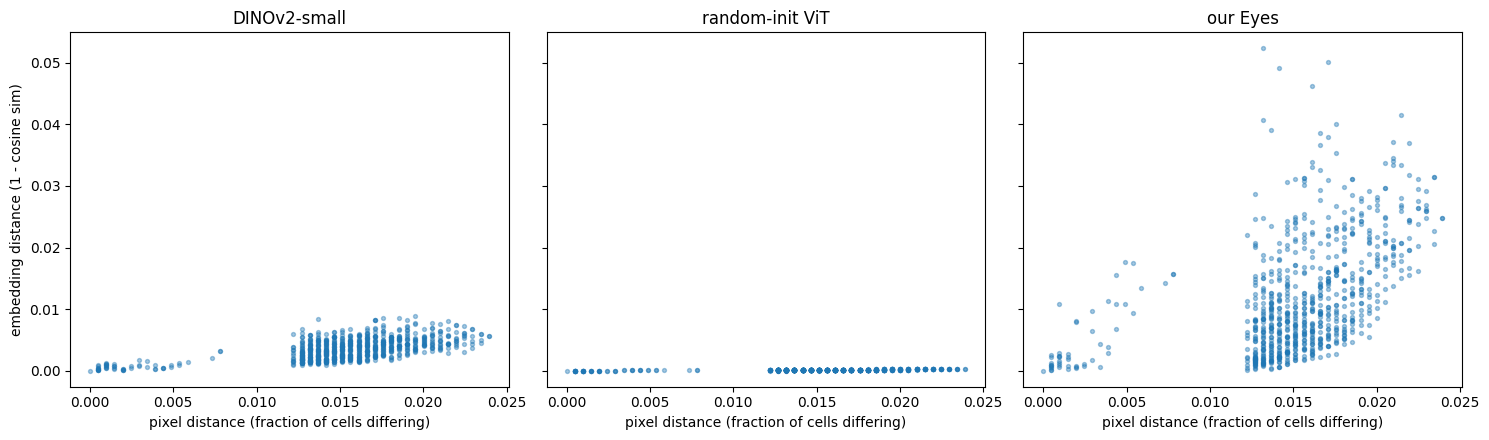


Verdict guide (not automatic -- eyeball the numbers/plots above):
- If DINOv2's correlation is clearly higher than random-init's: pretraining is doing
  something real here despite the domain mismatch, worth investigating further.
- If DINOv2 ~= random-init: any signal is just from having a big ViT, not from
  natural-image pretraining specifically -- supports the ARCHITECTURE.md rejection.
- Compare both against our own Eyes: is a tiny from-scratch encoder, trained for a few
  minutes on this project's own data, already competitive with a 22M-param pretrained one?


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
for ax, (name, d) in zip(axes, [("DINOv2-small", dino_d), ("random-init ViT", rand_d), ("our Eyes", eyes_d)]):
    ax.scatter(pixel_d[iu], d[iu], s=8, alpha=0.4)
    ax.set_xlabel("pixel distance (fraction of cells differing)")
    ax.set_title(name)
axes[0].set_ylabel("embedding distance (1 - cosine sim)")
plt.tight_layout()
plt.show()

print()
print("Verdict guide (not automatic -- eyeball the numbers/plots above):")
print("- If DINOv2's correlation is clearly higher than random-init's: pretraining is doing")
print("  something real here despite the domain mismatch, worth investigating further.")
print("- If DINOv2 ~= random-init: any signal is just from having a big ViT, not from")
print("  natural-image pretraining specifically -- supports the ARCHITECTURE.md rejection.")
print("- Compare both against our own Eyes: is a tiny from-scratch encoder, trained for a few")
print("  minutes on this project's own data, already competitive with a 22M-param pretrained one?")